In [ ]:
# PART 1: LOAD & EXPLORE DATA
# Import necessary packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn import metrics

%matplotlib inline
sns.set_style('whitegrid')


In [ ]:
# Loading the dataset into the Dataframe then show its shape and column names 
df = pd.read_csv('Housing.csv') 
print(df.shape) 
print(df.columns.tolist())

(545, 13)
['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'parking', 'prefarea', 'furnishingstatus']


In [23]:
# This shows the first 5 rows, data info and data description
print('First five (5) rows')
print(df.head())


First five (5) rows
      price  area  bedrooms  bathrooms  stories mainroad guestroom basement  \
0  13300000  7420         4          2        3      yes        no       no   
1  12250000  8960         4          4        4      yes        no       no   
2  12250000  9960         3          2        2      yes        no      yes   
3  12215000  7500         4          2        2      yes        no      yes   
4  11410000  7420         4          1        2      yes       yes      yes   

  hotwaterheating airconditioning  parking prefarea furnishingstatus  
0              no             yes        2      yes        furnished  
1              no             yes        3       no        furnished  
2              no              no        2      yes   semi-furnished  
3              no             yes        3      yes        furnished  
4              no             yes        2       no        furnished  


In [22]:
# This shows data info and data description
print(df.info())
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB
None
              price          area    bedrooms   bathrooms     stories  \
count  5.450000e+02    545.000000  545.000000  545.000000  545.000000   
mea

In [ ]:
# Checking for missing values in every column
df.isnull().sum()


price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

In [18]:
# Dropping the address column 
df = df.drop('Address', axis=1) 
print(df.columns.tolist()) 

KeyError: "['Address'] not found in axis"

In [17]:
print(df.columns.tolist())

['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'parking', 'prefarea', 'furnishingstatus']


In [24]:
# Printing the Heat map
plt.figure(figsize=(9, 7))


<Figure size 900x700 with 0 Axes>

<Figure size 900x700 with 0 Axes>

In [ ]:
# Checking the correlation matrix
num_column = ['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'parking']
df_corr = df[num_column].corr()
df_corr

,price,area,bedrooms,bathrooms,stories,parking
price,1.000000,0.535997,0.366494,0.517545,0.420712,0.384394
area,0.535997,1.000000,0.151858,0.193820,0.083996,0.352980
bedrooms,0.366494,0.151858,1.000000,0.373930,0.408564,0.139270
bathrooms,0.517545,0.193820,0.373930,1.000000,0.326165,0.177496
stories,0.420712,0.083996,0.408564,0.326165,1.000000,0.045547
parking,0.384394,0.352980,0.139270,0.177496,0.045547,1.000000


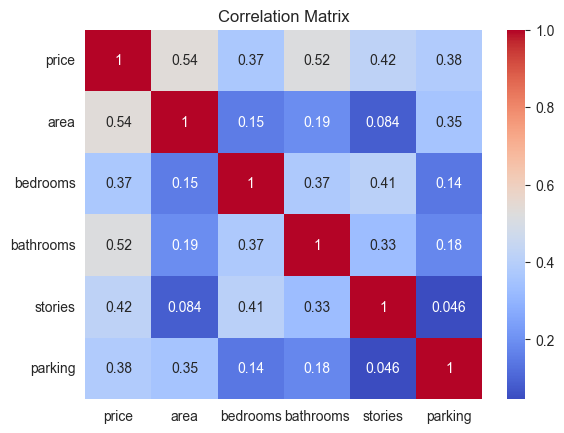

In [30]:
sns.heatmap(df[num_column].corr(), annot=True, cmap='coolwarm') 
plt.title('Correlation Matrix') 
plt.show()

Observation
Strongest Correlation
The feature that has the strongest correlation to Price is Area with a 0.54 rating
This is a moderate positive correlation and it suggests that the larger the properties, the higher the price

Lowest Correlation
Bedrooms has the lowest correlation to Price
It is still a positive correlation but weaker when compared to other property features in relation to Price

The correlation suggests that:
Area may be particularly useful for predicting house price.
Bathrooms may also provide substantial predictive information.
Stories and parking may contribute useful information.
Bedrooms has the weakest linear relationship with price among these features, so by itself it may be less informative


In [ ]:
# PART 2: SIMPLE LINEAR REGRESSION
#Using Average Area to predict Price
X = df[['area']] 
y = df['price'] 

# Spliting the data into training and test sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Verify the SPlit
print('Train size:', X_train.shape[0]) 
print('Test size:', X_test.shape[0]) 

Train size: 436
Test size: 109


In [35]:
# Create and fit a LinearRegression model on the training data. 
model_simple = LinearRegression() 
model_simple.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


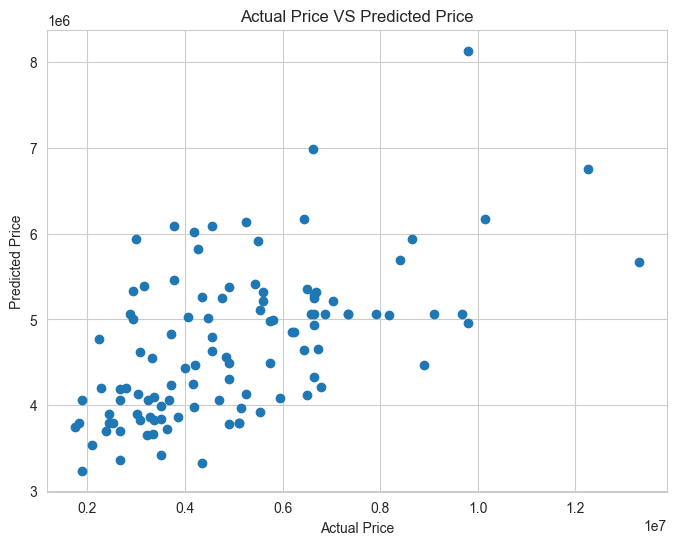

In [38]:
# Prediction on the test set
y_pred_simple = model_simple.predict(X_test)

plt.figure(figsize=(8, 6)) 
# Your scatter plot code here 
plt.scatter(y_test, y_pred_simple) 
plt.xlabel('Actual Price') 
plt.ylabel('Predicted Price') 
plt.title('Actual Price VS Predicted Price') 
plt.show()

In [ ]:
# Model's coeeficient and intercept
print('Coefficient:', model_simple.coef_[0]) 
print('Intercept:', model_simple.intercept_)

Coefficient: 425.72984193878284
Intercept: 2512254.2639593435


For every $1 increase in average area income, the model predicts that the house price will increase by approximately $425.73, holding other factors constant. The coefficient is positive, indicating a positive relationship between average area income and predicted house price.

In [ ]:
# PART 3
# MULTIPLE LINEAR REGRESSION

# Separate features and target
X_multi = df.drop('price', axis=1)
y_multi = df['price']


In [ ]:
# Encode categorical variables
X_multi = pd.get_dummies(
    X_multi,
    columns=[
        'mainroad',
        'guestroom',
        'basement',
        'hotwaterheating',
        'airconditioning',
        'prefarea',
        'furnishingstatus'
    ],
    drop_first=True,
    dtype=int
)


In [ ]:
# Split data into 80% training and 20% testing
X_train_multi, X_test_multi, y_train_multi, y_test_multi = train_test_split(
    X_multi,
    y_multi,
    test_size=0.2,
    random_state=42
)


In [ ]:
# Create the Multiple Linear Regression model
model_multi = LinearRegression()


# Train the model
model_multi.fit(X_train_multi, y_train_multi)

In [61]:
# Prediction on the test set
y_pred_multi = model_multi.predict(X_test_multi)


In [60]:
coeff_df = pd.DataFrame( 
model_multi.coef_, X_multi.columns, columns=['Coefficient'] 
) 
print(coeff_df) 

                                  Coefficient
area                             2.359688e+02
bedrooms                         7.677870e+04
bathrooms                        1.094445e+06
stories                          4.074766e+05
parking                          2.248419e+05
mainroad_yes                     3.679199e+05
guestroom_yes                    2.316100e+05
basement_yes                     3.902512e+05
hotwaterheating_yes              6.846499e+05
airconditioning_yes              7.914267e+05
prefarea_yes                     6.298906e+05
furnishingstatus_semi-furnished -1.268818e+05
furnishingstatus_unfurnished    -4.136451e+05


From the output, the largest coeeficient is:
Bathrooms with a value of 1.094445e+06

But this does not automatically means it is the most important feature in predicting Price and that is because the features are measured on diffrent scale. Features like Area, Bedrooms have different units and ranges


In [62]:
# PART 4
# EVALUATING & COMPARING BOTH MODELS

mae_simple = metrics.mean_absolute_error(y_test, y_pred_simple) 
mse_simple = metrics.mean_squared_error(y_test, y_pred_simple) 
rmse_simple = np.sqrt(mse_simple) 
r2_simple = metrics.r2_score(y_test, y_pred_simple) 
  
print('MAE:', mae_simple) 
print('MSE:', mse_simple) 
print('RMSE:', rmse_simple) 

MAE: 1474748.1337969352
MSE: 3675286604768.185
RMSE: 1917103.7021424233


In [63]:
mae_multi = metrics.mean_absolute_error(y_test_multi, y_pred_multi)
mse_multi = metrics.mean_squared_error(y_test_multi, y_pred_multi)
rmse_multi = np.sqrt(mse_multi)
r2_multi = metrics.r2_score(y_test_multi, y_pred_multi)

print('MAE:', mae_multi)
print('MSE:', mse_multi)
print('RMSE:', rmse_multi)
print('R2:', r2_multi)

MAE: 970043.4039201637
MSE: 1754318687330.6643
RMSE: 1324506.9600914388
R2: 0.6529242642153184


In [64]:
# Comparing both data

comparison = pd.DataFrame({ 
    'Simple (Income only)': [mae_simple, mse_simple, rmse_simple, r2_simple], 
    'Multiple (All features)': [mae_multi, mse_multi, rmse_multi, r2_multi] 
}, index=['MAE', 'MSE', 'RMSE', 'R2']) 
print(comparison) 

      Simple (Income only)  Multiple (All features)
MAE           1.474748e+06             9.700434e+05
MSE           3.675287e+12             1.754319e+12
RMSE          1.917104e+06             1.324507e+06
R2            2.728785e-01             6.529243e-01


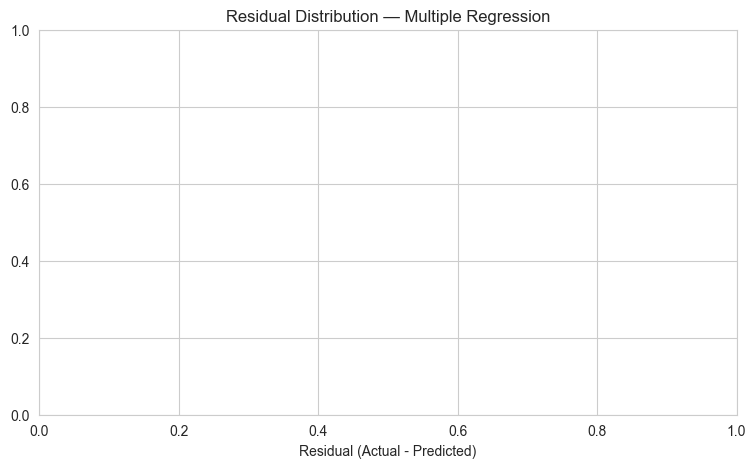

In [ ]:
# Plotting a histogram of the residuals (y_test − predictions) for the multiple regression model.

residuals = y_test_multi - y_pred_multi 
plt.figure(figsize=(9, 5))


plt.title('Residual Distribution — Multiple Regression') 
plt.xlabel('Residual (Actual - Predicted)') 
plt.show() 

The Multiple Regression model performed better than the Simple model on all four (4) metrics:
MAE decreased from approximtely 1.47 million to 970,043
MSE decreased from around 3.6 million to 1.7 million
RMSE also decreased from approximately 1.92 million to 1.32 million
R`2 increased from 0.273 to 0.653 which means that the Multiple Regression model explained approximately 65.3% of the variation in the house prices compared to 27.3% for the Simple model

Adding more features was worthwhile



In [ ]:
# BONUS PART
#Importing Polynomial Features

from sklearn.preprocessing import PolynomialFeatures 
poly = PolynomialFeatures(degree=2) 
X_poly = poly.fit_transform(X) 

In [67]:
# Splitting and Fitting Linear Regression model on the Polynomial features

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# Split the polynomial features into training and testing sets
X_train_poly, X_test_poly, y_train_poly, y_test_poly = train_test_split(
    X_poly, y, test_size=0.2, random_state=42
)

# Create and fit the Linear Regression model
model_poly = LinearRegression()
model_poly.fit(X_train_poly, y_train_poly)

# Make predictions
y_pred_poly = model_poly.predict(X_test_poly)

# Calculate R²
r2_poly = r2_score(y_test_poly, y_pred_poly)

print("Polynomial Regression R²:", r2_poly)

Polynomial Regression R²: 0.2952903678835116


#Observation

Yes. Polynomial regression improved on the simple linear regression for Avg. Area Income a little
The R`2 increased from 27.29% to 29.53%, an improvement of about 2.24 percentage points.

What might explain the result either way?
The polynomial model adds an Income`2 term, allowing the relationship between income and house price to curve rather than remain a straight line.